In [130]:
import pandas as pd
import numpy as np
import sklearn.tree 
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV, LassoCV, Lasso, LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

In [131]:
def PolyFeatures(X,degree=2,interaction_only=False):
    poly = PolynomialFeatures(degree,interaction_only=interaction_only)
    if X.ndim == 1:
        Xe = poly.fit_transform(X.values.reshape(-1,1))
        cols = poly.get_feature_names_out([X.name])
    else:
        Xe = poly.fit_transform(X)
        cols = poly.get_feature_names_out(X.columns)
    Xe = pd.DataFrame(Xe,columns=cols)
    print('X shape =',X.shape)
    print('X (engineered) shape =',Xe.shape)
    return Xe

In [132]:
df = pd.read_csv("dataset1.csv")
print(df.shape)
print(df.info())
df.head(5)

(11055, 32)
<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   index                         11055 non-null  int64
 1   having_IPhaving_IP_Address    11055 non-null  int64
 2   URLURL_Length                 11055 non-null  int64
 3   Shortining_Service            11055 non-null  int64
 4   having_At_Symbol              11055 non-null  int64
 5   double_slash_redirecting      11055 non-null  int64
 6   Prefix_Suffix                 11055 non-null  int64
 7   having_Sub_Domain             11055 non-null  int64
 8   SSLfinal_State                11055 non-null  int64
 9   Domain_registeration_length   11055 non-null  int64
 10  Favicon                       11055 non-null  int64
 11  port                          11055 non-null  int64
 12  HTTPS_token                   11055 non-null  int64
 13  Request_URL                   

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


# Simple Decision Tree Classifier

In [133]:
X = df.drop(columns=["Result"])
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
print(accuracy, error_rate)

0.9077340569877883 0.09226594301221169


In [134]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[ 801,  179],
       [  25, 1206]])

In [135]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

          -1       0.97      0.82      0.89       980
           1       0.87      0.98      0.92      1231

    accuracy                           0.91      2211
   macro avg       0.92      0.90      0.90      2211
weighted avg       0.91      0.91      0.91      2211



# Tuned Decision Tree Classifier

In [136]:
# max_depth = np.arange(5, 305, 50)
# max_depth = np.arange(10, 100, 10)
max_depth = np.arange(10, 30, 1)
grid = {'max_depth': max_depth}

In [137]:
tree = DecisionTreeClassifier(random_state=0)
treeCV = GridSearchCV(tree,param_grid=grid,return_train_score=True)
treeCV.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([10, 11... 27, 28, 29])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [138]:
print("Train Score: ", treeCV.best_estimator_.score(X_train, y_train), "\nValidation Score: ", treeCV.best_score_, "\nTest Score: ", treeCV.best_estimator_.score(X_test, y_test), "\nBest Parameters: ", treeCV.best_params_)

Train Score:  1.0 
Validation Score:  0.948440589437497 
Test Score:  0.9579375848032564 
Best Parameters:  {'max_depth': np.int64(23)}


In [139]:
treeCV.best_estimator_.fit(X_train, y_train)

y_pred = treeCV.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - error_rate

print("Tuned Decision Tree Classifier Results")
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print()

print("Confusion Matrix:")
M_pca_best = confusion_matrix(y_test, y_pred, labels=[-1, 1])
ConfusionMatrix_pca_best = pd.DataFrame(
    M_pca_best,
    index=["Legitimate (-1)", "Phishing (1)"],
    columns=["Legitimate (-1)", "Phishing (1)"]
)
ConfusionMatrix_pca_best["total"] = ConfusionMatrix_pca_best.sum(axis=1)
print(ConfusionMatrix_pca_best)
print()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[-1, 1],
    target_names=["Legitimate (-1)", "Phishing (1)"]
))

Tuned Decision Tree Classifier Results
Accuracy: 0.9579375848032564
Error Rate: 0.9077340569877883

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              925            55    980
Phishing (1)                  38          1193   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.96      0.94      0.95       980
   Phishing (1)       0.96      0.97      0.96      1231

       accuracy                           0.96      2211
      macro avg       0.96      0.96      0.96      2211
   weighted avg       0.96      0.96      0.96      2211



# PCA

In [140]:
n_comp = X_train.shape[1]
# n_comp = 15
print('number of components',n_comp)

number of components 31


In [141]:
# create column names
cols = ['PC-'+str(i+1) for i in range(n_comp)]

In [142]:
stnd = StandardScaler()
X_train_scaled = stnd.fit_transform(X_train)
X_test_scaled = stnd.transform(X_test)

PC-1     0.17
PC-2     0.13
PC-3     0.08
PC-4     0.06
PC-5     0.05
PC-6     0.04
PC-7     0.04
PC-8     0.04
PC-9     0.03
PC-10    0.03
PC-11    0.03
PC-12    0.03
PC-13    0.03
PC-14    0.03
PC-15    0.03
PC-16    0.02
PC-17    0.02
PC-18    0.02
PC-19    0.01
PC-20    0.01
PC-21    0.01
PC-22    0.01
PC-23    0.01
PC-24    0.01
PC-25    0.01
PC-26    0.01
PC-27    0.01
PC-28    0.01
PC-29    0.01
PC-30    0.00
PC-31    0.00
dtype: float64


<Axes: title={'center': 'PVE'}>

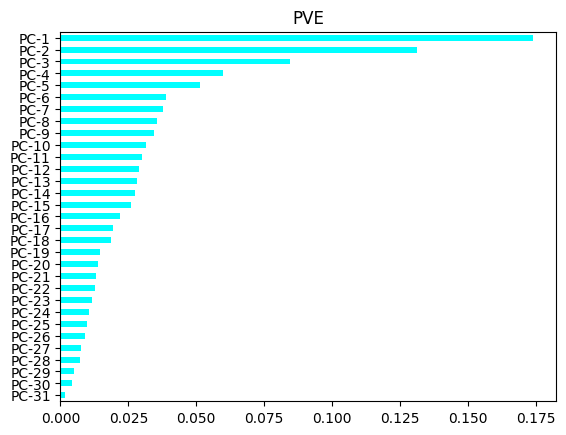

In [143]:
pca = PCA(n_components=n_comp)
pca.fit(X_train_scaled)
PVE = pca.explained_variance_ratio_
PVE = pd.Series(PVE,index=cols)
print(PVE.round(2))
PVE.sort_values().plot.barh(color='cyan',title='PVE')

In [144]:
pca_results = []

component_options = [3, 5, 9, 15, 18, 23, 27, 30, X_train_scaled.shape[1]]

for n in component_options:
    pca_temp = PCA(n_components=n)
    
    X_train_pca_temp = pca_temp.fit_transform(X_train_scaled)
    
    model_temp = DecisionTreeClassifier(random_state=0)
    
    scores = cross_val_score(model_temp, X_train_pca_temp, y_train, cv=5, scoring="accuracy")
    
    pca_results.append({"num_components": n, "accuracy": scores.mean()})

pca_results = pd.DataFrame(pca_results)

print("PCA CV Results")
print(pca_results)
print("Best number of PCA components:", pca_results.iloc[pca_results["accuracy"].argmax()]["num_components"])
best_num_components = int(pca_results.iloc[pca_results["accuracy"].argmax()]["num_components"])

PCA CV Results
   num_components  accuracy
0               3  0.874153
1               5  0.911128
2               9  0.923790
3              15  0.926617
4              18  0.922660
5              23  0.923678
6              27  0.921643
7              30  0.921530
8              31  0.921191
Best number of PCA components: 15.0


In [145]:
pca_best = PCA(n_components=best_num_components)

X_train_pca_best = pca_best.fit_transform(X_train_scaled)
X_test_pca_best = pca_best.transform(X_test_scaled)

In [146]:
pca_tree = DecisionTreeClassifier(random_state=0)
pca_treeCV = GridSearchCV(tree,param_grid=grid,return_train_score=True)
pca_treeCV.fit(X_train_pca_best, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([10, 11... 27, 28, 29])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [147]:
print("Train Score: ", pca_treeCV.best_estimator_.score(X_train_pca_best, y_train), "\nValidation Score: ", pca_treeCV.best_score_, "\nTest Score: ", pca_treeCV.best_estimator_.score(X_test_pca_best, y_test), "\nBest Parameters: ", pca_treeCV.best_params_)

Train Score:  1.0 
Validation Score:  0.9271821260573629 
Test Score:  0.9222071460877431 
Best Parameters:  {'max_depth': np.int64(20)}


In [148]:
pca_treeCV.best_estimator_.fit(X_train_pca_best, y_train)

y_pred_pca_best = pca_treeCV.best_estimator_.predict(X_test_pca_best)

accuracy_pca_best = accuracy_score(y_test, y_pred_pca_best)
error_rate_pca_best = 1 - accuracy_pca_best

print("Tuned PCA + Decision Tree Classifier Results")
print("Accuracy:", accuracy_pca_best)
print("Error Rate:", error_rate_pca_best)
print()

print("Confusion Matrix:")
M_pca_best = confusion_matrix(y_test, y_pred_pca_best, labels=[-1, 1])
ConfusionMatrix_pca_best = pd.DataFrame(
    M_pca_best,
    index=["Legitimate (-1)", "Phishing (1)"],
    columns=["Legitimate (-1)", "Phishing (1)"]
)
ConfusionMatrix_pca_best["total"] = ConfusionMatrix_pca_best.sum(axis=1)
print(ConfusionMatrix_pca_best)
print()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_pca_best,
    labels=[-1, 1],
    target_names=["Legitimate (-1)", "Phishing (1)"]
))

Tuned PCA + Decision Tree Classifier Results
Accuracy: 0.9222071460877431
Error Rate: 0.07779285391225688

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              895            85    980
Phishing (1)                  87          1144   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.91      0.91      0.91       980
   Phishing (1)       0.93      0.93      0.93      1231

       accuracy                           0.92      2211
      macro avg       0.92      0.92      0.92      2211
   weighted avg       0.92      0.92      0.92      2211



# PCA + Feature Engineering

In [149]:
Xe_train = PolyFeatures(X_train, 2)
Xe_test = PolyFeatures(X_test, 2)

Xe_train_scaled = stnd.fit_transform(Xe_train)
Xe_test_scaled = stnd.fit_transform(Xe_test)

X shape = (8844, 31)
X (engineered) shape = (8844, 528)
X shape = (2211, 31)
X (engineered) shape = (2211, 528)


In [150]:
tree = DecisionTreeClassifier(random_state=0)
treeCV = GridSearchCV(tree,param_grid=grid,return_train_score=True)
treeCV.fit(Xe_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([10, 11... 27, 28, 29])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [151]:
n_comp = Xe_train_scaled.shape[1]
print('number of components',n_comp)
# create column names
cols = ['PC-'+str(i+1) for i in range(n_comp)]

number of components 528


PC-1      0.10
PC-2      0.06
PC-3      0.05
PC-4      0.04
PC-5      0.03
          ... 
PC-524    0.00
PC-525    0.00
PC-526    0.00
PC-527    0.00
PC-528    0.00
Length: 528, dtype: float64


<Axes: title={'center': 'PVE'}>

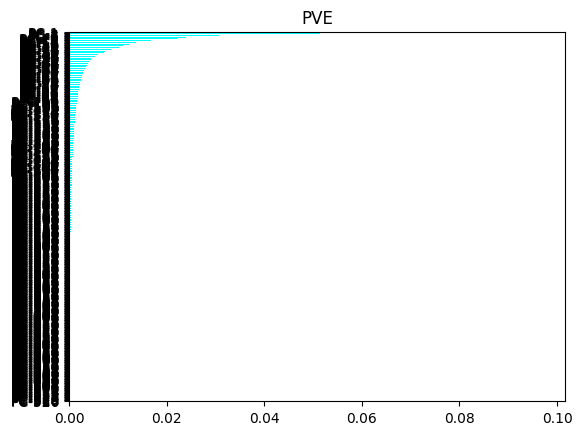

In [152]:
pca = PCA(n_components=n_comp)
pca.fit(Xe_train_scaled)
PVE = pca.explained_variance_ratio_
PVE = pd.Series(PVE,index=cols)
print(PVE.round(2))
PVE.sort_values().plot.barh(color='cyan',title='PVE')

In [153]:
pca_results = []

component_options = [50, 100, 150, 200, 250, 300, 450, 500, Xe_train_scaled.shape[1]]

for n in component_options:
    pca_temp = PCA(n_components=n)
    
    Xe_train_pca_temp = pca_temp.fit_transform(Xe_train_scaled)
    
    model_temp = DecisionTreeClassifier(random_state=0)
    
    scores = cross_val_score(model_temp, X_train_pca_temp, y_train, cv=5, scoring="accuracy")
    
    pca_results.append({"num_components": n, "accuracy": scores.mean()})

pca_results = pd.DataFrame(pca_results)

print("PCA CV Results")
print(pca_results)
print("Best number of PCA components:", pca_results.iloc[pca_results["accuracy"].argmax()]["num_components"])
best_num_components = int(pca_results.iloc[pca_results["accuracy"].argmax()]["num_components"])

PCA CV Results
   num_components  accuracy
0              50  0.921191
1             100  0.921191
2             150  0.921191
3             200  0.921191
4             250  0.921191
5             300  0.921191
6             450  0.921191
7             500  0.921191
8             528  0.921191
Best number of PCA components: 50.0


In [154]:
pca_best = PCA(n_components=best_num_components)

X_train_pca_best = pca_best.fit_transform(Xe_train_scaled)
X_test_pca_best = pca_best.transform(Xe_test_scaled)

In [155]:
pca_tree = DecisionTreeClassifier(random_state=0)
pca_treeCV = GridSearchCV(tree,param_grid=grid,return_train_score=True)
pca_treeCV.fit(X_train_pca_best, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([10, 11... 27, 28, 29])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [156]:
print("Train Score: ", pca_treeCV.best_estimator_.score(X_train_pca_best, y_train), "\nValidation Score: ", pca_treeCV.best_score_, "\nTest Score: ", pca_treeCV.best_estimator_.score(X_test_pca_best, y_test), "\nBest Parameters: ", pca_treeCV.best_params_)

Train Score:  0.9862053369516056 
Validation Score:  0.9225476980373399 
Test Score:  0.9253731343283582 
Best Parameters:  {'max_depth': np.int64(13)}


In [157]:
pca_treeCV.best_estimator_.fit(X_train_pca_best, y_train)

y_pred_pca_best = pca_treeCV.best_estimator_.predict(X_test_pca_best)

accuracy_pca_best = accuracy_score(y_test, y_pred_pca_best)
error_rate_pca_best = 1 - accuracy_pca_best

print("Tuned PCA + Feature Engineering + Decision Tree Classifier Results")
print("Accuracy:", accuracy_pca_best)
print("Error Rate:", error_rate_pca_best)
print()

print("Confusion Matrix:")
M_pca_best = confusion_matrix(y_test, y_pred_pca_best, labels=[-1, 1])
ConfusionMatrix_pca_best = pd.DataFrame(
    M_pca_best,
    index=["Legitimate (-1)", "Phishing (1)"],
    columns=["Legitimate (-1)", "Phishing (1)"]
)
ConfusionMatrix_pca_best["total"] = ConfusionMatrix_pca_best.sum(axis=1)
print(ConfusionMatrix_pca_best)
print()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_pca_best,
    labels=[-1, 1],
    target_names=["Legitimate (-1)", "Phishing (1)"]
))

Tuned PCA + Feature Engineering + Decision Tree Classifier Results
Accuracy: 0.9253731343283582
Error Rate: 0.07462686567164178

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              893            87    980
Phishing (1)                  78          1153   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.92      0.91      0.92       980
   Phishing (1)       0.93      0.94      0.93      1231

       accuracy                           0.93      2211
      macro avg       0.92      0.92      0.92      2211
   weighted avg       0.93      0.93      0.93      2211

